Oppgi region (Trondheim eller Bergen):  bergen
Oppgi startpopulasjon for bergen:  200000
Oppgi årlig vekstrate (i prosent, f.eks. 2 for 2%):  2
Oppgi startår:  2000
Oppgi sluttsåret du ønsker å beregne for:  2023


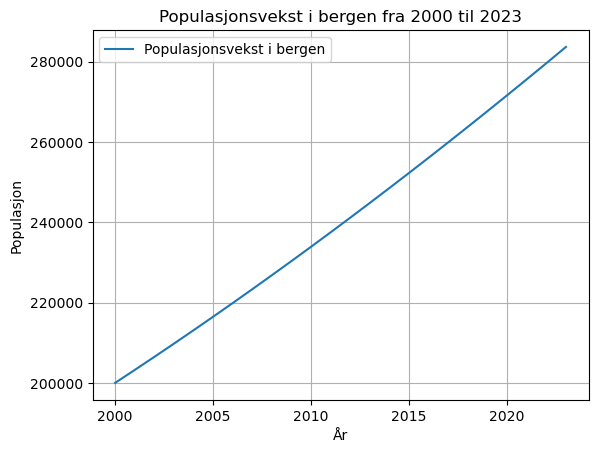


Populasjonen i bergen ved år 2023 er estimert til: 283677
Absolutt vekst: 83677 mennesker
Relativ vekst: 41.84%


In [1]:
import math
import matplotlib.pyplot as plt

# Funksjon for å beregne populasjonen på et gitt tidspunkt t
def populasjonsvekst(P0, r, K, t):
    A = (K - P0) / P0
    Pt = K / (1 + A * math.exp(-r * t))
    return Pt

# Inndata for Trondheim og Bergen
region = input("Oppgi region (Trondheim eller Bergen): ")
startpopulasjon = float(input(f"Oppgi startpopulasjon for {region}: "))
vekstrate = float(input("Oppgi årlig vekstrate (i prosent, f.eks. 2 for 2%): ")) / 100
startår = int(input("Oppgi startår: "))
sluttår = int(input("Oppgi sluttsåret du ønsker å beregne for: "))
makspopulasjon = 1000000  # Maksimum populasjon

# Beregn antall år (t)
år = sluttår - startår

# Lagre tidspunkter og populasjonene for hvert år
års_liste = list(range(0, år + 1))
populasjonsliste = [populasjonsvekst(startpopulasjon, vekstrate, makspopulasjon, t) for t in års_liste]

# Plot populasjonsveksten
plt.plot([startår + t for t in års_liste], populasjonsliste, label=f"Populasjonsvekst i {region}")
plt.title(f"Populasjonsvekst i {region} fra {startår} til {sluttår}")
plt.xlabel("År")
plt.ylabel("Populasjon")
plt.grid(True)
plt.legend()

# Vis grafen
plt.show()

# Beregn sluttpopulasjonen
sluttpopulasjon = populasjonsliste[-1]

# Beregn absolutt og relativ vekst
absolutt_vekst = sluttpopulasjon - startpopulasjon
relativ_vekst = (absolutt_vekst / startpopulasjon) * 100

# Skriv ut resultatene
print(f"\nPopulasjonen i {region} ved år {sluttår} er estimert til: {sluttpopulasjon:.0f}")
print(f"Absolutt vekst: {absolutt_vekst:.0f} mennesker")
print(f"Relativ vekst: {relativ_vekst:.2f}%")



  Kundenavn               Yrke Utdanning  Inntekt  Sparepenger
4   Kunde_5  Butikkmedarbeider  Bachelor   622794       123022
     Kundenavn               Yrke Utdanning  Inntekt  Sparepenger
76    Kunde_77              Lærer       PhD   370692       212941
78    Kunde_79               Lege    Master   338710       205121
83    Kunde_84       IT-konsulent       PhD   398524       226219
97    Kunde_98  Butikkmedarbeider  Bachelor   584722       204467
113  Kunde_114  Butikkmedarbeider    Master   511350       282885


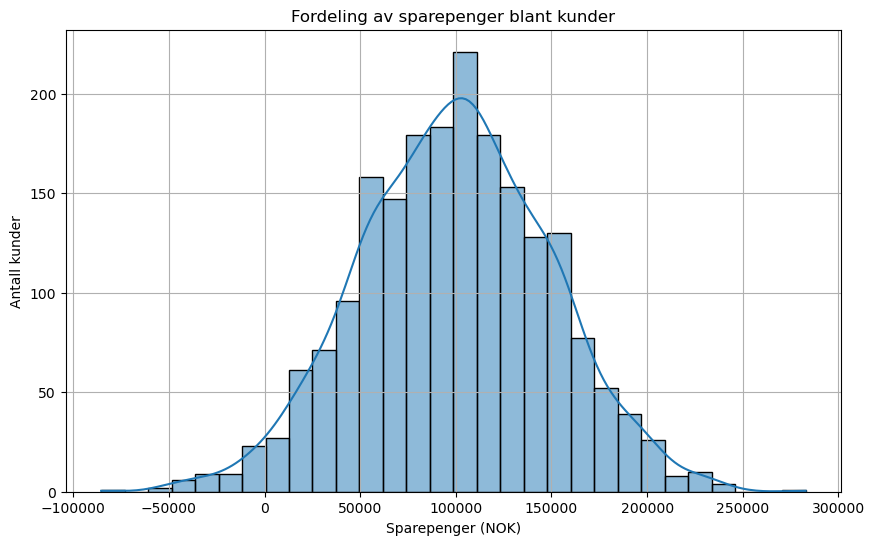

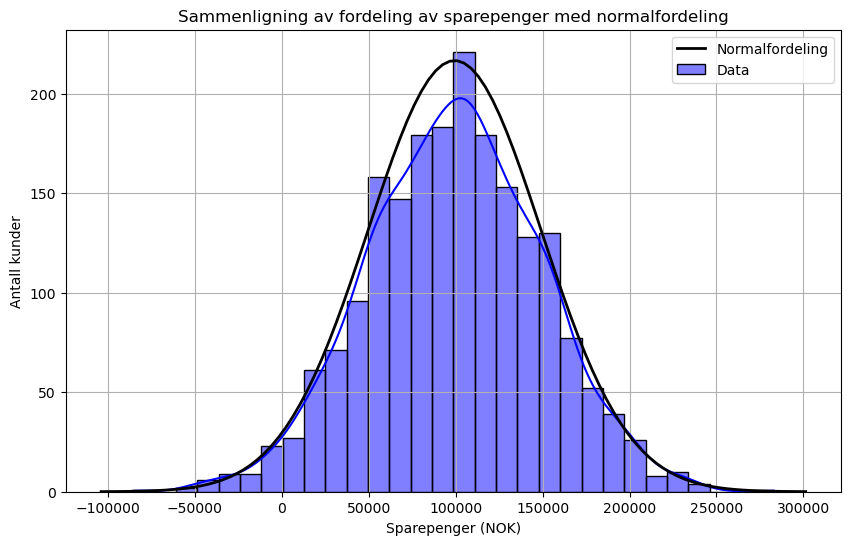

Statistikk for Sparepenger:
Gjennomsnitt: 99425.29
Median: 100084.00
Varians: 2475574164.09
Standardavvik: 49755.14


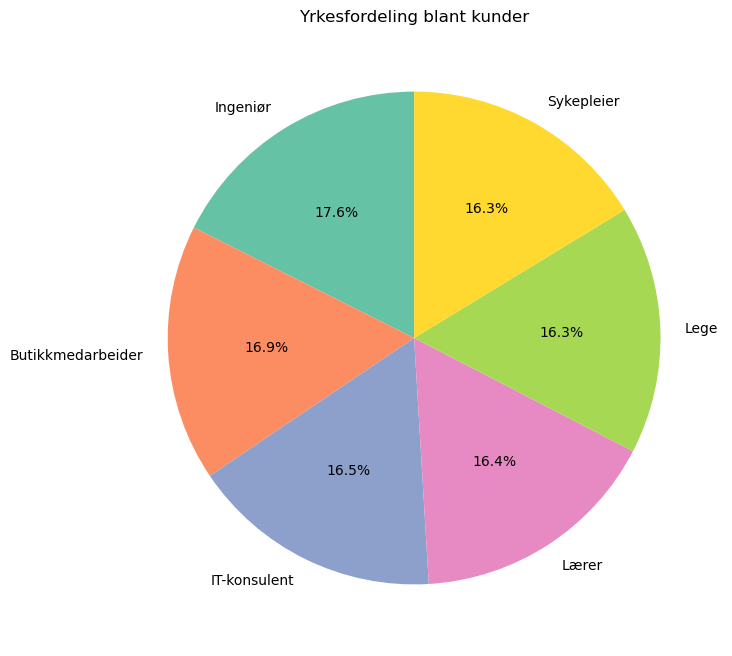

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Sett frø for reproducerbarhet
np.random.seed(42)

# Definer lister over yrker og utdanninger
yrker = ['Ingeniør', 'Lærer', 'Sykepleier', 'Lege', 'Butikkmedarbeider', 'IT-konsulent']
utdanning = ['Bachelor', 'Master', 'PhD', 'Videregående skole']

# Generer datasett med 2000 kunder
antall_kunder = 2000

# Generer tilfeldige data for kundene
data = {
    'Kundenavn': [f'Kunde_{i}' for i in range(1, antall_kunder + 1)],
    'Yrke': np.random.choice(yrker, antall_kunder),
    'Utdanning': np.random.choice(utdanning, antall_kunder),
    'Inntekt': np.random.normal(500000, 150000, antall_kunder).astype(int),  # Årlig inntekt
    'Sparepenger': np.random.normal(100000, 50000, antall_kunder).astype(int)  # Sparepenger
}

# Lag DataFrame
kunder = pd.DataFrame(data)

# Funksjon for å hente ut informasjon om en spesifikk kunde
def hent_kundeinfo(kundenavn):
    kunde = kunder[kunder['Kundenavn'] == kundenavn]
    if kunde.empty:
        print("Kunden finnes ikke.")
    else:
        print(kunde)

# Funksjon for å filtrere kunder basert på sparepenger
def filtrer_kunder_saldo(min_saldo):
    filtrerte_kunder = kunder[kunder['Sparepenger'] >= min_saldo]
    return filtrerte_kunder

# Funksjon for å plotte fordeling av sparepenger
def plot_fordeling_sparepenger():
    plt.figure(figsize=(10, 6))
    sns.histplot(kunder['Sparepenger'], bins=30, kde=True)
    plt.title("Fordeling av sparepenger blant kunder")
    plt.xlabel("Sparepenger (NOK)")
    plt.ylabel("Antall kunder")
    plt.grid(True)
    plt.show()

# Funksjon for å sammenligne sparepengefordeling med teoretisk normalfordeling
def plot_normalfordeling():
    mu, std = norm.fit(kunder['Sparepenger'])

    plt.figure(figsize=(10, 6))
    sns.histplot(kunder['Sparepenger'], bins=30, kde=True, label="Data", color='blue')

    # Legg til teoretisk normalfordeling
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p * len(kunder) * (xmax - xmin) / 30, 'k', linewidth=2, label="Normalfordeling")
    plt.title("Sammenligning av fordeling av sparepenger med normalfordeling")
    plt.xlabel("Sparepenger (NOK)")
    plt.ylabel("Antall kunder")
    plt.legend()
    plt.grid(True)
    plt.show()

# Funksjon for å beregne statistiske nøkkeltall
def beregn_statistikk(kolonne):
    gjennomsnitt = np.mean(kunder[kolonne])
    median = np.median(kunder[kolonne])
    varians = np.var(kunder[kolonne])
    std_avvik = np.std(kunder[kolonne])
    print(f"Statistikk for {kolonne}:")
    print(f"Gjennomsnitt: {gjennomsnitt:.2f}")
    print(f"Median: {median:.2f}")
    print(f"Varians: {varians:.2f}")
    print(f"Standardavvik: {std_avvik:.2f}")

# Funksjon for å vise kakediagram av yrkesfordelingen
def plot_yrkesfordeling():
    plt.figure(figsize=(8, 8))
    yrkesfordeling = kunder['Yrke'].value_counts()
    plt.pie(yrkesfordeling, labels=yrkesfordeling.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
    plt.title("Yrkesfordeling blant kunder")
    plt.show()

# Eksempelbruk av funksjonene:

# 1. Hente kundeinfo
hent_kundeinfo('Kunde_5')

# 2. Filtrer kunder med sparepenger over 200 000
filtrerte_kunder = filtrer_kunder_saldo(200000)
print(filtrerte_kunder.head())

# 3. Plot fordeling av sparepenger
plot_fordeling_sparepenger()

# 4. Sammenlign fordeling med normalfordeling
plot_normalfordeling()

# 5. Beregn statistikk for sparepenger
beregn_statistikk('Sparepenger')

# 6. Plot kakediagram for yrkesfordeling
plot_yrkesfordeling()



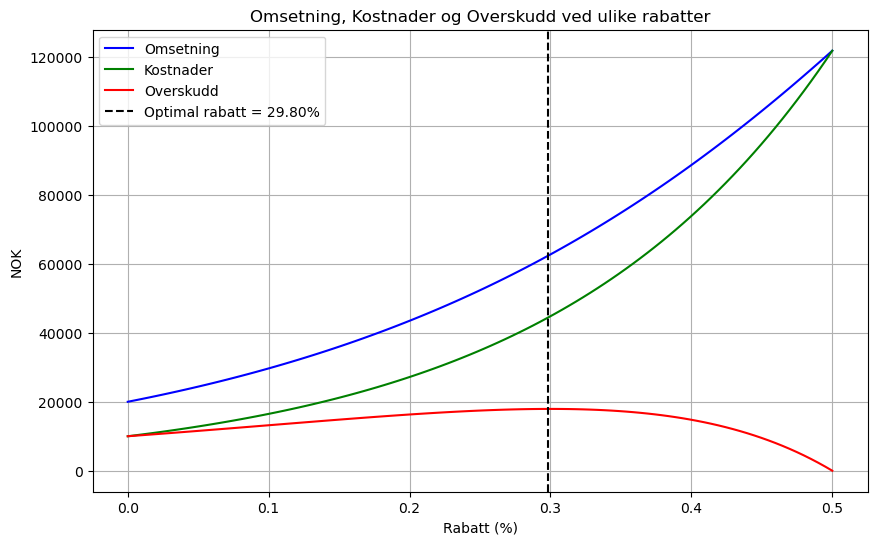

Maksimalt overskudd er 17925.85 NOK ved en rabatt på 29.80%.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definer grunnparametere for varene
innkjøpspris = 50  # Pris per enhet for innkjøp
opprinnelig_salgspris = 100  # Full pris uten rabatt
maks_rabatt = 0.5  # Maksimal rabatt på 50 %
dekningsgrad = 0.3  # Fortjenesten som prosentandel av salgspris

# 2. Definer en funksjon som estimerer antall solgte varer basert på rabatt
def antall_solgte_varer(rabatt):
    """
    Antall solgte varer øker eksponentielt jo større rabatten blir.
    """
    # Dette er en antatt funksjon der større rabatter gir mer salg
    return 200 * np.exp(5 * rabatt)

# 3. Kalkuler omsetning, kostnader og overskudd basert på salgsprisen og rabatten
rabatter = np.linspace(0, maks_rabatt, 100)  # Teste rabatter mellom 0% og 50%

salgspriser = opprinnelig_salgspris * (1 - rabatter)  # Salgspris basert på rabatt
solgte_varer = antall_solgte_varer(rabatter)  # Antall varer solgt ved gitt rabatt
omsetning = salgspriser * solgte_varer  # Omsetning = salgspris * antall solgte varer
kostnader = innkjøpspris * solgte_varer  # Kostnader = innkjøpspris * antall solgte varer
overskudd = (salgspriser - innkjøpspris) * solgte_varer  # Fortjeneste = (pris - innkjøpspris) * antall varer

# 4. Finn rabatten som maksimerer overskuddet
maks_overskudd_index = np.argmax(overskudd)
optimal_rabatt = rabatter[maks_overskudd_index]
maks_overskudd = overskudd[maks_overskudd_index]

# 5. Plot resultatene
plt.figure(figsize=(10, 6))

# Plot omsetning, kostnader og overskudd
plt.plot(rabatter, omsetning, label="Omsetning", color='blue')
plt.plot(rabatter, kostnader, label="Kostnader", color='green')
plt.plot(rabatter, overskudd, label="Overskudd", color='red')

# Marker den optimale rabatten
plt.axvline(optimal_rabatt, color='black', linestyle='--', label=f"Optimal rabatt = {optimal_rabatt:.2%}")
plt.title("Omsetning, Kostnader og Overskudd ved ulike rabatter")
plt.xlabel("Rabatt (%)")
plt.ylabel("NOK")
plt.legend()
plt.grid(True)
plt.show()

# 6. Skriv ut resultatene
print(f"Maksimalt overskudd er {maks_overskudd:.2f} NOK ved en rabatt på {optimal_rabatt:.2%}.")
